In [1]:
'''
RAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)
'''

'\nRAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)\n'

In [2]:
possible_games = ['axis-allies-rules-1942-2nd-edition',
 'Axis_&_Allies_1942_2nd_Reference_v1',
 'Grand_Austria_Hotel_game_aid_-_2_pages_v1',
 'Grand_Austria_Hotel_Plain_and_Simple_Guide',
 'Grand_Hotel_Austria_rules_EN_web',
 'In_The_Footsteps_Of_Marco_Polo_-_English_Overview_Cards',
 'LlamaLand_Player_Aid_(English)_version_2',
 'LlamaLand_Rules_EN',
 'Memoir_44_-_a_beginners_reference',
 'memoir_44_rules_part1_en',
 'Memoir_44_Unofficial_FAQ_v12',
 'munchkindisneyrules',
 'MunchkinDisney_Instr',
 'MYSTERIUM_PARK_RULES_EN_BD',
 'Mysterium_Park_Rules_Summary_unnofficial',
 'Paleo_FAQ_11-12-20_ENG',
 'Paleo_Rulebook_EN_compressed',
 'pandemic season 1 rules',
 'partners',
 'Partners_rules',
 'Power Grid Expansion Benelux Central Europe',
 'Power Grid Expansion India Australia',
 'Power Grid Expansion UK Ireland Northern Europe',
 'Power-Grid-Recharged-Rules',
 'skull_king_rulebook_optimized',
 'splendor',
 'Splendor_Brief_by_Liumas_2014-05b',
 'Take-5-or-6-Nimmt-Rules',
 'Take_5_6nimmt30_rules_english',
 'The_Crew_Demo_Sheet',
 'The_Crew_Manual',
 'Tureluurs official rules EN',
 'Tureluurs official rules',
 'Tureluurs unofficial rules',
 'Voyages Of Marco Polo - English Rules V3',
 'Voyages_Of_Marco_Polo_-_FAQ_and_Errata_V2']

In [4]:



# Useful to set working directory
from pathlib import Path

# Useful to load api keys for Cohere embeddings and generative model
import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 
from langchain_cohere import CohereEmbeddings
from langchain.chat_models import init_chat_model

# For connecting to the embeddings vector store
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# For declaring functions as tools to be used by the generative model
from langchain_core.tools import tool

# For declaring nodes
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

#For creating the graph
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition

#For adding memory to the graph
from langgraph.checkpoint.memory import MemorySaver

#For logging
import logging

logger = logging.getLogger(__name__)

    

print('We started running rag script')


######################


# Set working directory
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent.parent

#temp: delete later
base_dir = Path().resolve().parent

########################


# Declare both embeddings and generative models
#embeddings = CohereEmbeddings(model="embed-v4.0") # Langchain wrapper does not allow reducing size to 256
embeddings = CohereEmbeddings(model="embed-multilingual-light-v3.0")  # This dimension is 384. Default of v4.0: 1536

model = init_chat_model("command-a-03-2025", model_provider="cohere") # Cohere api key needs to be as env variable with the name COHERE_API_KEY



########################



# Connect to Qdrant vector store
path_qdrant_vector_store = base_dir / "data" /  "qdrant"
client = QdrantClient(path=path_qdrant_vector_store)
vector_store = QdrantVectorStore(
    client=client,
    collection_name="document_embeddings",
    embedding=embeddings,
)


######################


# Approach via Chains
#Our graph will consist of three nodes:

    #1- A node that fields the user input, either generating a query for the retriever or responding directly; (this is cool and we did not have it before)
    #2- A node for the retriever tool that executes the retrieval step
    #3- A node that generates the final response using the retrieved context.


### Tools used in the nodes of the graph: ###

#Tool to retrieve data from embeddings store
#An agent decides which tool to use based on the tool's names, descriptions, and argument schemas
@tool(response_format="content_and_artifact") # This will make it possible for a chat model to call this function
def retrieve(query: str): # This receives a string as input and not a state bc it is not a node. This tool will be added into a node, that needs as input a State
    """Retrieve information related to a query."""
    logger.debug("Start of retrieval tool")
    nr_vector_store_documents=client.count(collection_name=vector_store.collection_name).count  # Works for Qdrant vector_store
    logger.debug(f'Size of vector store until now: {nr_vector_store_documents}')
    logger.debug(f"Starts vector similarity search")
    # This is were the app crashes due to lack of memory
    retrieved_docs = vector_store.similarity_search(query, k=4) # Tried this to make it lighter but never worked(query, k=1, search_params={"ef": 4})
    logger.debug("Vector similarity done")
    serialized = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") 
        for doc in retrieved_docs 
    )
    logger.debug("End of retrieval tool")
    return serialized, retrieved_docs  # if you use @tool(response_format="content_and_artifact"), you must return exactly a tuple of two elements
#First element → This is what will be used as the main textual output (like a summary or answer).
#Second element → This is any additional data (e.g. a document, list of sources, JSON, etc.) that might be useful for tracking, inspection, or chaining.


### Nodes used in the graph: ###

# Node 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    logger.debug("Start of query_or_respond node")
    llm_with_tools = model.bind_tools([retrieve]) # Tells the chat model it can use the retrieve tool
    response = llm_with_tools.invoke(state["messages"]) 
    # "response" is an AIMessage object with the content of the message and some metadata
    # This metadata also says if you must call a Tool or not, and which tool to call
    # MessagesState appends messages to state instead of overwriting
    output = {"messages": [response]}
    logger.debug("End of query_or_respond node")
    logger.debug(f"Output of query_or_respond node: {output}")
    return output

# Node 2: Execute the retrieval.
#ToolNode executes the tool and adds the result as a ToolMessage to the state. (This is important info)
#I think this addition only happens when running it inside a graph for a particular state, not if you run it independently
tools = ToolNode([retrieve])

# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: MessagesState): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    logger.debug("Start of node generate")
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        #print(message.content) #Useful to see what is appended in the message
        if message.type == "tool":
            recent_tool_messages.append(message.content) #appends only tool messages'content (not metadata!) (outputs from the retriever)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #orders them from first to last 

    # Format into prompt
    docs_content = "\n\n".join(doc for doc in tool_messages) # I dont see the need of this if we already joined contexts in tools. 
    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (outputs of the retriever are already added in system_message_content)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    logger.debug(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    logger.debug("End of generate node")
    return {"messages": [response]} # MessagesState appends messages to state instead of overwriting



### Declaration of the graph ###


graph_builder = StateGraph(MessagesState) #Input of the graph is of the type MessagesState
#declaration of nodes
graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)
#set starting node
graph_builder.set_entry_point("query_or_respond") 
#set conditional node
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
#link rest of nodes
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)
#declaration of memory
memory = MemorySaver()
#graph compilation
graph = graph_builder.compile(checkpointer=memory)


print('We finished running rag script')





We started running rag script
We finished running rag script


# What was before (to be deleted)

In [1]:

# Useful to set working directory
from pathlib import Path

# Useful to load api keys for Cohere embeddings and generative model
import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 
from langchain_cohere import CohereEmbeddings
from langchain.chat_models import init_chat_model

# For connecting to the embeddings vector store
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# For declaring functions as tools to be used by the generative model
from langchain_core.tools import tool

# For declaring nodes
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

#For creating the graph
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition

#For adding memory to the graph
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Set working directory
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent

In [3]:
# Declare both embeddings and generative models
embeddings = CohereEmbeddings(model="embed-v4.0")
model = init_chat_model("command-a-03-2025", model_provider="cohere") # Cohere api key needs to be as env variable with the name COHERE_API_KEY


In [4]:
# Connect to Qdrant vector store
path_qdrant_vector_store = base_dir / "data" /  "qdrant"
client = QdrantClient(path=path_qdrant_vector_store)
vector_store = QdrantVectorStore(
    client=client,
    collection_name="document_embeddings",
    embedding=embeddings,
)

In [5]:
# Check number of records in the embedding vector store
client.count(collection_name=vector_store.collection_name).count


721

In [6]:
# Approach via Chains
#Our graph will consist of three nodes:

    #1- A node that fields the user input, either generating a query for the retriever or responding directly; (this is cool and we did not have it before)
    #2- A node for the retriever tool that executes the retrieval step
    #3- A node that generates the final response using the retrieved context.


### Tools used in the nodes of the graph: ###

#Tool to retrieve data from embeddings store
#An agent decides which tool to use based on the tool's names, descriptions, and argument schemas
@tool(response_format="content_and_artifact") # This will make it possible for a chat model to call this function
def retrieve(query: str): # This receives a string as input and not a state bc it is not a node. This tool will be added into a node, that needs as input a State
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=4)
    serialized = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") 
        for doc in retrieved_docs 
    )
    print('Retrieval of data successful')
    return serialized, retrieved_docs  # if you use @tool(response_format="content_and_artifact"), you must return exactly a tuple of two elements
#First element → This is what will be used as the main textual output (like a summary or answer).
#Second element → This is any additional data (e.g. a document, list of sources, JSON, etc.) that might be useful for tracking, inspection, or chaining.


### Nodes used in the graph: ###

# Node 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = model.bind_tools([retrieve]) # Tells the chat model it can use the retrieve tool
    response = llm_with_tools.invoke(state["messages"]) 
    # "response" is an AIMessage object with the content of the message and some metadata
    # This metadata also says if you must call a Tool or not, and which tool to call
    # MessagesState appends messages to state instead of overwriting
    output = {"messages": [response]}
    print(output)
    return output

# Node 2: Execute the retrieval.
#ToolNode executes the tool and adds the result as a ToolMessage to the state. (This is important info)
#I think this addition only happens when running it inside a graph for a particular state, not if you run it independently
tools = ToolNode([retrieve])

# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: MessagesState): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        #print(message.content) #Useful to see what is appended in the message
        if message.type == "tool":
            recent_tool_messages.append(message.content) #appends only tool messages'content (not metadata!) (outputs from the retriever)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #orders them from first to last 

    # Format into prompt
    docs_content = "\n\n".join(doc for doc in tool_messages) # I dont see the need of this if we already joined contexts in tools. 
    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (outputs of the retriever are already added in system_message_content)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    print(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    return {"messages": [response]} # MessagesState appends messages to state instead of overwriting


### Declaration of the graph ###

graph_builder = StateGraph(MessagesState) #Input of the graph is of the type MessagesState
#declaration of nodes
graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)
#set starting node
graph_builder.set_entry_point("query_or_respond") 
#set conditional node
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
#link rest of nodes
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)
#declaration of memory
memory = MemorySaver()
#graph compilation
graph = graph_builder.compile(checkpointer=memory)


# End of code to be tested. Now testing starts

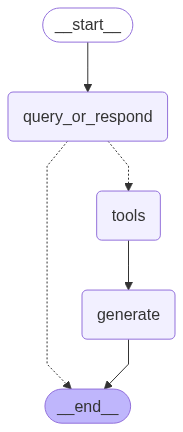

In [5]:
# To visualize flow: 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [6]:


# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [ ]:
input_message='How do you win at power grid?'

graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

c:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\.venv\lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=9223fd47-d799-4dd2-a056-e529aa6bbf62; trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=27e2c1ac-9b7b-4389-ae52-86893662f262; trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=0dbf14e6-4cf1-440b-94b0-24f398c0e617
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='81447ff1-f54e-4057-86b7-18fd90c830b5'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--0dbf14e6

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=4c16cc78-fc89-4edc-9882-d4ecd4922b93; trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=545c5e98-a661-4fc2-9081-38f6ea34d6e9; trace=9223fd47-d799-4dd2-a056-e529aa6bbf62,id=9223fd47-d799-4dd2-a056-e529aa6bbf62
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=debc8639-9208-4ffb-ab75-53c8d56d37b6,id=debc8639-9208-4ffb-ab75-53c8d56d37b6; trace=debc8639-9208-4ffb-ab75-53c8d56d37b6,id=8b09658e-4b91-487b-9e1d-cb3bae412837; trace=debc8639-

In [8]:
#input_message='How do you win at paleo?'
input_message='What was my last question?'
#input_message='Good morning Cohere chatbot!'
#input_message='Up to how many players can Monopoly be played?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='81447ff1-f54e-4057-86b7-18fd90c830b5'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--0dbf14e6

In [9]:
input_message='How do you win at Memoir?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='81447ff1-f54e-4057-86b7-18fd90c830b5'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--0dbf14e6

In [16]:
input_message='In Tureluurs, what does the "Lost binoculars" card do?'

answer=graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

In [17]:
answer

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='81447ff1-f54e-4057-86b7-18fd90c830b5'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--0dbf14e6